In [64]:
%reload_ext autoreload
%autoreload 2


# Can we improve the theoretical or emperical performance of the ILP run?
Ideas
- LP relaxation
- Cutting planes
- unimodularity proof
- assignment problem - hungarian algorithm

In [63]:
from cereeberus import Interleave, MapperGraph, Assignment
import cereeberus.data.ex_mappergraphs as ex_mg
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import cereeberus.distance.ilp as ilp_copy
from itertools import combinations



In [ ]:
"""
TU Diagnostic Workflow for ILP Complexity Analysis
====================================================
Usage:
    from tu_diagnostic import run_full_workflow
    run_full_workflow(list_of_assignment_objects)

Requires:
    - pulp
    - numpy
    - your Assignment class (myAssgn) and its helpers
    - build_ilp() refactored from solve_ilp() — see bottom of this file
"""

import pulp
import numpy as np
from itertools import combinations


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: BUILD ILP WITHOUT SOLVING
# Refactor of solve_ilp — paste your existing build logic here.
# ══════════════════════════════════════════════════════════════════════════════

def build_ilp(myAssgn):
    """
    Builds the PuLP ILP problem from an Assignment object WITHOUT solving it.
    This is a direct refactor of solve_ilp() — copy everything up to prob.solve().

    Returns:
        prob         : the PuLP LpProblem (unsolved)
        phi_vars     : dict of phi decision variables
        psi_vars     : dict of psi decision variables
        z_vars       : dict of z auxiliary variables
        map_prod_vars: dict of map product variables
        func_vals    : list of function values (block indices)
    """
    func_vals = myAssgn.all_func_vals()

    prob = pulp.LpProblem("Interleave_Optimization_Problem", pulp.LpMinimize)

    # ── phi / psi vars ────────────────────────────────────────────────────────
    phi_vars = {
        block: {thick: {ot: {} for ot in ["V", "E"]} for thick in ["0", "n"]}
        for block in func_vals
    }
    psi_vars = {
        block: {thick: {ot: {} for ot in ["V", "E"]} for thick in ["0", "n"]}
        for block in func_vals
    }

    for thickening in ["0", "n"]:
        for obj_type in ["V", "E"]:
            for block in (func_vals[:-1] if obj_type == "E" else func_vals):

                nr = myAssgn.phi(thickening, obj_type)[block].get_array().shape[0]
                nc = myAssgn.phi(thickening, obj_type)[block].get_array().shape[1]
                phi_vars[block][thickening][obj_type] = pulp.LpVariable.dicts(
                    "phi_" + thickening + obj_type + "_" + str(block),
                    ((a, b) for a in range(nr) for b in range(nc)),
                    cat="Binary",
                )

                nr = myAssgn.psi(thickening, obj_type)[block].get_array().shape[0]
                nc = myAssgn.psi(thickening, obj_type)[block].get_array().shape[1]
                psi_vars[block][thickening][obj_type] = pulp.LpVariable.dicts(
                    "psi_" + thickening + obj_type + "_" + str(block),
                    ((a, b) for a in range(nr) for b in range(nc)),
                    cat="Binary",
                )

    # ── z vars and map_product vars ───────────────────────────────────────────
    z_vars = {
        block: {sm: {ot: {} for ot in ["V", "E"]} for sm in ["F", "G"]}
        for block in func_vals
    }
    map_product_vars = {
        block: {sm: {ot: {} for ot in ["V", "E"]} for sm in ["F", "G"]}
        for block in func_vals
    }wh

    for obj_type in ["V", "E"]:
        for starting_map in ["F", "G"]:
            for block in (func_vals[:-1] if obj_type == "E" else func_vals):
                if starting_map == "F":
                    nr1 = myAssgn.psi("n", obj_type)[block].get_array().shape[0]
                    nc1 = myAssgn.phi("0", obj_type)[block].get_array().shape[1]
                    map_product_vars[block][starting_map][obj_type] = pulp.LpVariable.dicts(
                        starting_map + "_" + obj_type + "_" + str(block),
                        ((a, b) for a in range(nr1) for b in range(nc1)),
                        cat="Integer",
                    )
                    nrc = myAssgn.psi("n", obj_type)[block].get_array().shape[1]
                    z_vars[block][starting_map][obj_type] = pulp.LpVariable.dicts(
                        "z_" + starting_map + "_" + obj_type + "_" + str(block),
                        ((a, b, c) for a in range(nr1) for b in range(nrc) for c in range(nc1)),
                        cat="Binary",
                    )
                else:
                    nr1 = myAssgn.phi("n", obj_type)[block].get_array().shape[0]
                    nc1 = myAssgn.psi("0", obj_type)[block].get_array().shape[1]
                    map_product_vars[block][starting_map][obj_type] = pulp.LpVariable.dicts(
                        starting_map + "_" + obj_type + "_" + str(block),
                        ((a, b) for a in range(nr1) for b in range(nc1)),
                        cat="Integer",
                    )
                    nrc = myAssgn.phi("n", obj_type)[block].get_array().shape[1]
                    z_vars[block][starting_map][obj_type] = pulp.LpVariable.dicts(
                        "z_" + starting_map + "_" + obj_type + "_" + str(block),
                        ((a, b, c) for a in range(nr1) for b in range(nrc) for c in range(nc1)),
                        cat="Binary",
                    )

    # ── constraints ───────────────────────────────────────────────────────────
    for block in func_vals:
        for starting_map in ["F", "G"]:
            if block not in myAssgn.all_func_vals(map=starting_map):
                continue
            other_map = "G" if starting_map == "F" else "F"

            for up_or_down in ["up", "down"]:
                if block == myAssgn.all_func_vals(map=starting_map)[-1]:
                    continue
                if up_or_down == "up":
                    bou_n = myAssgn.B_up(other_map, "n")[block].get_array()
                    bou_0 = myAssgn.B_up(starting_map, "0")[block].get_array()
                    if starting_map == "F":
                        map_V_vars = phi_vars[block + 1]["0"]["V"]
                        map_E_vars = phi_vars[block]["0"]["E"]
                        map_V = myAssgn.phi("0", "V")[block + 1].get_array()
                        map_E = myAssgn.phi("0", "E")[block].get_array()
                    else:
                        map_V_vars = psi_vars[block + 1]["0"]["V"]
                        map_E_vars = psi_vars[block]["0"]["E"]
                        map_V = myAssgn.psi("0", "V")[block + 1].get_array()
                        map_E = myAssgn.psi("0", "E")[block].get_array()
                else:
                    bou_n = myAssgn.B_down(other_map, "n")[block].get_array()
                    bou_0 = myAssgn.B_down(starting_map, "0")[block].get_array()
                    if starting_map == "F":
                        map_V_vars = phi_vars[block]["0"]["V"]
                        map_E_vars = phi_vars[block]["0"]["E"]
                        map_V = myAssgn.phi("0", "V")[block].get_array()
                        map_E = myAssgn.phi("0", "E")[block].get_array()
                    else:
                        map_V_vars = psi_vars[block]["0"]["V"]
                        map_E_vars = psi_vars[block]["0"]["E"]
                        map_V = myAssgn.psi("0", "V")[block].get_array()
                        map_E = myAssgn.psi("0", "E")[block].get_array()

                sm_mix = map_V.shape[0]
                sn_mix = map_V.shape[1]
                so_mix = bou_n.shape[1]
                sp_mix = map_E.shape[1]

                for i in range(sm_mix):
                    for k in range(sp_mix):
                        first_term  = pulp.lpSum(map_V_vars[i, j] * bou_0[j][k] for j in range(sn_mix))
                        second_term = pulp.lpSum(bou_n[i][l] * map_E_vars[l, k] for l in range(so_mix))
                        prob += (first_term - second_term) == 0

                for j in range(sn_mix):
                    prob += pulp.lpSum(map_V_vars[h, j] for h in range(sm_mix)) == 1
                for k in range(sp_mix):
                    prob += pulp.lpSum(map_E_vars[l, k] for l in range(so_mix)) == 1

            for obj_type in ["V", "E"]:
                if obj_type == "E" and block == func_vals[-1]:
                    continue

                i_n_i_0   = myAssgn.I(starting_map, "n", obj_type)[block].get_array() \
                           @ myAssgn.I(starting_map, "0", obj_type)[block].get_array()
                inc_0_para = myAssgn.I(starting_map, "0", obj_type)[block].get_array()
                inc_n_para = myAssgn.I(other_map,    "n", obj_type)[block].get_array()

                if starting_map == "F":
                    map_0_para_vars = phi_vars[block]["0"][obj_type]
                    map_n_para_vars = phi_vars[block]["n"][obj_type]
                else:
                    map_0_para_vars = psi_vars[block]["0"][obj_type]
                    map_n_para_vars = psi_vars[block]["n"][obj_type]

                sm_tri = i_n_i_0.shape[0]
                so_para = myAssgn.I(other_map,    "n", obj_type)[block].get_array().shape[1]
                sn_para = myAssgn.I(starting_map, "0", obj_type)[block].get_array().shape[0]

                if starting_map == "F":
                    sn_tri = myAssgn.psi("n", obj_type)[block].get_array().shape[1]
                    so_tri = myAssgn.phi("0", obj_type)[block].get_array().shape[1]
                    sm_para = myAssgn.phi("n", obj_type)[block].get_array().shape[0]
                    sp_para = myAssgn.phi("0", obj_type)[block].get_array().shape[1]
                else:
                    sn_tri = myAssgn.phi("n", obj_type)[block].get_array().shape[1]
                    so_tri = myAssgn.psi("0", obj_type)[block].get_array().shape[1]
                    sm_para = myAssgn.psi("n", obj_type)[block].get_array().shape[0]
                    sp_para = myAssgn.psi("0", obj_type)[block].get_array().shape[1]

                for h in range(sm_tri):
                    for k in range(so_tri):
                        prob += map_product_vars[block][starting_map][obj_type][h, k] == float(i_n_i_0[h, k])

                for i in range(sm_para):
                    for k in range(sp_para):
                        first_term  = pulp.lpSum(map_n_para_vars[i, j] * inc_0_para[j][k] for j in range(sn_para))
                        second_term = pulp.lpSum(inc_n_para[i][l] * map_0_para_vars[l, k] for l in range(so_para))
                        prob += (first_term - second_term) == 0

                for i in range(sm_tri):
                    for k in range(so_tri):
                        prob += map_product_vars[block][starting_map][obj_type][i, k] == \
                                pulp.lpSum(z_vars[block][starting_map][obj_type][i, j, k] for j in range(sn_tri))

                for i in range(sm_tri):
                    for j in range(sn_tri):
                        for k in range(so_tri):
                            if starting_map == "F":
                                prob += z_vars[block][starting_map][obj_type][i, j, k] <= psi_vars[block]["n"][obj_type][i, j]
                                prob += z_vars[block][starting_map][obj_type][i, j, k] <= phi_vars[block]["0"][obj_type][j, k]
                                prob += z_vars[block][starting_map][obj_type][i, j, k] >= psi_vars[block]["n"][obj_type][i, j] \
                                                                                         + phi_vars[block]["0"][obj_type][j, k] - 1
                            else:
                                prob += z_vars[block][starting_map][obj_type][i, j, k] <= phi_vars[block]["n"][obj_type][i, j]
                                prob += z_vars[block][starting_map][obj_type][i, j, k] <= psi_vars[block]["0"][obj_type][j, k]
                                prob += z_vars[block][starting_map][obj_type][i, j, k] >= phi_vars[block]["n"][obj_type][i, j] \
                                                                                         + psi_vars[block]["0"][obj_type][j, k] - 1

                if starting_map == "F":
                    for j in range(sn_tri):
                        prob += pulp.lpSum(psi_vars[block]["n"][obj_type][i, j] for i in range(sm_tri)) == 1
                    for k in range(so_tri):
                        prob += pulp.lpSum(phi_vars[block]["0"][obj_type][j, k] for j in range(sn_tri)) == 1
                    for j in range(sn_para):
                        prob += pulp.lpSum(phi_vars[block]["n"][obj_type][i, j] for i in range(sm_para)) == 1
                    for k in range(sp_para):
                        prob += pulp.lpSum(phi_vars[block]["0"][obj_type][j, k] for j in range(so_para)) == 1
                else:
                    for j in range(sn_tri):
                        prob += pulp.lpSum(phi_vars[block]["n"][obj_type][i, j] for i in range(sm_tri)) == 1
                    for k in range(so_tri):
                        prob += pulp.lpSum(psi_vars[block]["0"][obj_type][j, k] for j in range(sn_tri)) == 1
                    for j in range(sn_para):
                        prob += pulp.lpSum(psi_vars[block]["n"][obj_type][i, j] for i in range(sm_para)) == 1
                    for k in range(sp_para):
                        prob += pulp.lpSum(psi_vars[block]["0"][obj_type][j, k] for j in range(so_para)) == 1

    prob += 0  # no objective

    return prob, phi_vars, psi_vars, z_vars, map_product_vars, func_vals


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: EXTRACT CONSTRAINT MATRIX A
# ══════════════════════════════════════════════════════════════════════════════

def extract_constraint_matrix(prob):
    """
    Extracts the constraint matrix A and RHS vector b from an unsolved PuLP problem.

    Returns:
        A         : np.ndarray of shape (n_constraints, n_vars)
        b         : np.ndarray of shape (n_constraints,)
        var_index : dict mapping variable name -> column index in A
    """
    vars_list = prob.variables()
    var_index = {v.name: i for i, v in enumerate(vars_list)}
    n_vars = len(vars_list)

    rows, rhs = [], []
    for name, constraint in prob.constraints.items():
        row = np.zeros(n_vars)
        for var, coef in constraint.items():
            row[var_index[var.name]] = coef
        rows.append(row)
        rhs.append(-constraint.constant)

    return np.array(rows), np.array(rhs), var_index


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: TU TESTS
# ══════════════════════════════════════════════════════════════════════════════

def test_tu_sampled(A, sample_size=2000, max_submat_size=8, seed=42):
    """
    Randomly samples square submatrices and checks determinants ∈ {-1, 0, 1}.

    Returns:
        violations : list of dicts with keys rows, cols, det, submatrix
                     Empty list means no violations found in sample.
    """
    rng = np.random.default_rng(seed)
    n_rows, n_cols = A.shape
    violations = []

    for _ in range(sample_size):
        k = int(rng.integers(2, min(max_submat_size, min(n_rows, n_cols)) + 1))
        rows = rng.choice(n_rows, k, replace=False)
        cols = rng.choice(n_cols, k, replace=False)
        submat = A[np.ix_(rows, cols)]
        det = int(round(np.linalg.det(submat)))
        if abs(det) > 1:
            violations.append({
                "rows": rows.tolist(),
                "cols": cols.tolist(),
                "det": det,
                "submatrix": submat.copy(),
            })

    return violations


def test_tu_exhaustive(A, max_size=5):
    """
    Exhaustively checks ALL square submatrices up to (max_size x max_size).
    Only use for small problems (n_cols <= ~50). Fails fast on first violation.

    Returns:
        violations : list of dicts (same format as test_tu_sampled).
                     Empty list means provably no violations up to max_size.
    """
    n_rows, n_cols = A.shape
    violations = []

    for k in range(2, max_size + 1):
        for rows in combinations(range(n_rows), k):
            for cols in combinations(range(n_cols), k):
                submat = A[np.ix_(rows, cols)]
                det = int(round(np.linalg.det(submat)))
                if abs(det) > 1:
                    violations.append({
                        "rows": list(rows),
                        "cols": list(cols),
                        "det": det,
                        "submatrix": submat.copy(),
                    })
                    return violations  # fail fast

    return violations


def classify_violation(violation, prob, var_index):
    """
    Given a TU violation (a dict from the tests above), identify which
    constraint TYPES are involved so you know which part of the ILP
    is breaking TU.

    Prints a breakdown of constraint names involved in the violating submatrix.
    """
    constraint_names = list(prob.constraints.keys())
    row_indices = violation["rows"]

    print("  Violating constraint types:")
    for r in row_indices:
        cname = constraint_names[r]
        # Heuristic: parse the PuLP auto-generated name
        if "phi" in cname or "psi" in cname:
            ctype = "phi/psi commutativity"
        elif "_c" in cname:
            ctype = "column-sum-to-1"
        elif "z_" in cname:
            ctype = "z AND-encoding"
        else:
            ctype = "other"
        print(f"    Row {r}: {cname[:60]}  →  [{ctype}]")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: LP INTEGRALITY CHECK
# ══════════════════════════════════════════════════════════════════════════════

def check_lp_integrality(myAssgn, tol=1e-6):
    """
    Solves the LP relaxation (all binary/integer vars → continuous [0,1])
    and checks whether the solution is fully integral.

    This is the most direct practical evidence for TU:
    - If LP always returns integral solutions → TU almost certainly holds
    - If LP returns fractional solutions → TU fails, pursue flow reduction

    Returns:
        is_integral      : bool
        fractional_vars  : list of (name, value) for fractional variables
        lp_status        : PuLP status string
    """
    prob, *_ = build_ilp(myAssgn)

    # Relax all vars to continuous [0, 1]
    for v in prob.variables():
        v.cat = pulp.constants.LpContinuous
        v.lowBound = 0.0
        v.upBound = 1.0

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    lp_status = pulp.LpStatus[prob.status]

    if prob.status != 1:
        print(f"  LP relaxation status: {lp_status} (infeasible → ILP also infeasible)")
        return False, [], lp_status

    fractional_vars = []
    for v in prob.variables():
        val = v.varValue
        if val is not None and abs(val - round(val)) > tol:
            fractional_vars.append((v.name, val))

    is_integral = len(fractional_vars) == 0
    return is_integral, fractional_vars, lp_status


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: GHOUILA-HOURI PARTITION CHECK
# Checks the sufficient condition for TU using your integer lattice structure.
# ══════════════════════════════════════════════════════════════════════════════

def check_ghouila_houri(A, func_vals, n_rows_per_block):
    """
    Checks the Ghouila-Houri sufficient condition for TU.

    Partitions rows by even/odd block index (natural partition for integer lattice).
    For every column j, checks that:
        |sum_{R1} A[i,j] - sum_{R2} A[i,j]| <= 1

    Args:
        A               : constraint matrix from extract_constraint_matrix
        func_vals       : list of block indices (integers)
        n_rows_per_block: dict mapping block index -> number of constraint rows
                          (you can compute this by counting constraints per block)

    Returns:
        passed          : bool — True if condition holds for all columns
        failing_cols    : list of column indices that violate the condition
    """
    n_rows, n_cols = A.shape

    # Build row→block assignment from n_rows_per_block
    row_partition = np.zeros(n_rows, dtype=int)
    row_idx = 0
    for block in func_vals:
        n = n_rows_per_block.get(block, 0)
        parity = func_vals.index(block) % 2  # 0=even, 1=odd
        row_partition[row_idx: row_idx + n] = parity
        row_idx += n

    failing_cols = []
    for j in range(n_cols):
        col = A[:, j]
        r1_sum = col[row_partition == 0].sum()
        r2_sum = col[row_partition == 1].sum()
        if abs(r1_sum - r2_sum) > 1:
            failing_cols.append(j)

    return len(failing_cols) == 0, failing_cols


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: FULL WORKFLOW RUNNER
# ══════════════════════════════════════════════════════════════════════════════

def run_full_workflow(test_instances, exhaustive_threshold=50):
    """
    Runs the complete TU diagnostic workflow on a list of Assignment objects.

    Args:
        test_instances        : list of Assignment objects
        exhaustive_threshold  : if n_vars <= this, run exhaustive TU test
                                instead of sampled

    Prints a full report and returns a summary dict.

    Interpretation guide (printed at end):
        ALL_INTEGRAL + NO_TU_VIOLATIONS → strong evidence for TU → pursue Ghouila-Houri proof
        FRACTIONAL or TU_VIOLATIONS     → TU fails → pursue flow reduction
    """
    summary = {
        "total": len(test_instances),
        "lp_integral": 0,
        "lp_fractional": 0,
        "lp_infeasible": 0,
        "tu_passed": 0,
        "tu_violated": 0,
        "details": [],
    }

    print("=" * 70)
    print("TU DIAGNOSTIC WORKFLOW")
    print("=" * 70)

    for idx, instance in enumerate(test_instances):
        print(f"\n── Instance {idx + 1}/{len(test_instances)} ──")
        detail = {"instance": idx, "lp_integral": None, "tu_passed": None}

        # ── Step 1: LP integrality check ──────────────────────────────────────
        print("  [1/3] LP relaxation integrality check...")
        is_integral, frac_vars, lp_status = check_lp_integrality(instance)

        if lp_status != "Optimal":
            print(f"  ✗ LP infeasible (status: {lp_status}) — skipping TU tests")
            summary["lp_infeasible"] += 1
            detail["lp_integral"] = None
            detail["tu_passed"] = None
            summary["details"].append(detail)
            continue

        if is_integral:
            print("  ✓ LP solution is fully integral")
            summary["lp_integral"] += 1
            detail["lp_integral"] = True
        else:
            print(f"  ✗ LP solution has {len(frac_vars)} fractional variable(s)")
            for name, val in frac_vars[:5]:
                print(f"      {name} = {val:.6f}")
            if len(frac_vars) > 5:
                print(f"      ... and {len(frac_vars) - 5} more")
            summary["lp_fractional"] += 1
            detail["lp_integral"] = False

        # ── Step 2: Extract A and run TU test ─────────────────────────────────
        print("  [2/3] Building constraint matrix A...")
        prob, *_ = build_ilp(instance)
        A, b, var_index = extract_constraint_matrix(prob)
        print(f"  A shape: {A.shape}  (rows=constraints, cols=variables)")

        use_exhaustive = A.shape[1] <= exhaustive_threshold
        if use_exhaustive:
            print(f"  [3/3] Running EXHAUSTIVE TU test (n_vars={A.shape[1]} ≤ {exhaustive_threshold})...")
            violations = test_tu_exhaustive(A, max_size=5)
            test_type = "exhaustive"
        else:
            print(f"  [3/3] Running SAMPLED TU test (n_vars={A.shape[1]} > {exhaustive_threshold}, 2000 samples)...")
            violations = test_tu_sampled(A, sample_size=2000)
            test_type = "sampled"

        if violations:
            print(f"  ✗ TU VIOLATED ({test_type}) — {len(violations)} violation(s)")
            print(f"    First violation: det = {violations[0]['det']}")
            print(f"    Submatrix:\n{violations[0]['submatrix']}")
            classify_violation(violations[0], prob, var_index)
            summary["tu_violated"] += 1
            detail["tu_passed"] = False
            detail["violations"] = violations
        else:
            print(f"  ✓ No TU violations found ({test_type})")
            summary["tu_passed"] += 1
            detail["tu_passed"] = True

        summary["details"].append(detail)

    # ── Final report ──────────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"  Instances tested    : {summary['total']}")
    print(f"  LP integral         : {summary['lp_integral']}")
    print(f"  LP fractional       : {summary['lp_fractional']}")
    print(f"  LP infeasible       : {summary['lp_infeasible']}")
    print(f"  TU test passed      : {summary['tu_passed']}")
    print(f"  TU test violated    : {summary['tu_violated']}")
    print()

    # ── Interpretation ────────────────────────────────────────────────────────
    all_integral   = summary["lp_fractional"] == 0 and summary["lp_infeasible"] == 0
    no_violations  = summary["tu_violated"] == 0

    print("INTERPRETATION:")
    if all_integral and no_violations:
        print("  ✓ STRONG EVIDENCE FOR TU")
        print("    → LP relaxation always returns integral solutions")
        print("    → No submatrix determinant violations found")
        print("    → Next step: prove Ghouila-Houri partition formally")
        print("    → This would give polynomial-time solvability O((B|V|^2)^3.5)")
    elif not all_integral and no_violations:
        print("  ~ AMBIGUOUS: LP fractional but no submatrix violations")
        print("    → TU may hold but sampler missed violations")
        print("    → Run exhaustive test on small instances")
        print("    → Also consider that near-TU may allow rounding")
    elif all_integral and not no_violations:
        print("  ~ AMBIGUOUS: LP integral but submatrix violations exist")
        print("    → Violations may be in inactive constraints")
        print("    → Check if violations only occur in z_vars block")
        print("    → Consider partial TU (TU on subproblem excluding z_vars)")
    else:
        print("  ✗ TU FAILS")
        print("    → LP gives fractional solutions AND submatrix violations exist")
        print("    → Next step: pursue flow network reduction")
        print("    → Column-sum-to-1 + commutativity = likely reducible to")
        print("       min-cost flow on integer lattice O(B * |V|^3)")

    print("=" * 70)
    return summary


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: QUICK SINGLE-INSTANCE ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

def diagnose_one(myAssgn, exhaustive=False):
    """
    Quick diagnostic on a single Assignment object.
    Useful during development to check one instance before running the full batch.

    Example:
        from tu_diagnostic import diagnose_one
        diagnose_one(my_assignment_object, exhaustive=True)
    """
    return run_full_workflow([myAssgn], exhaustive_threshold=50 if exhaustive else 0)


In [4]:
T = ex_mg.torus(0, 2, 10, 13, delta = 1, seed = 17)
L = ex_mg.line(0, 12)

myAssgn = Assignment(T, L, n = 2)


In [5]:


diagnose_one(myAssgn, exhaustive=True)




TU DIAGNOSTIC WORKFLOW

── Instance 1/1 ──
  [1/3] LP relaxation integrality check...
  ✓ LP solution is fully integral
  [2/3] Building constraint matrix A...
  A shape: (879, 276)  (rows=constraints, cols=variables)
  [3/3] Running SAMPLED TU test (n_vars=276 > 50, 2000 samples)...
  ✓ No TU violations found (sampled)

SUMMARY
  Instances tested    : 1
  LP integral         : 1
  LP fractional       : 0
  LP infeasible       : 0
  TU test passed      : 1
  TU test violated    : 0

INTERPRETATION:
  ✓ STRONG EVIDENCE FOR TU
    → LP relaxation always returns integral solutions
    → No submatrix determinant violations found
    → Next step: prove Ghouila-Houri partition formally
    → This would give polynomial-time solvability O((B|V|^2)^3.5)


{'total': 1,
 'lp_integral': 1,
 'lp_fractional': 0,
 'lp_infeasible': 0,
 'tu_passed': 1,
 'tu_violated': 0,
 'details': [{'instance': 0, 'lp_integral': True, 'tu_passed': True}]}

In [6]:
prob, phi_vars, psi_vars, z_vars, map_prod_vars, func_vals = build_ilp(myAssgn)

A,  b, var_index = extract_constraint_matrix(prob)


def count_constraints_per_block(myAssgn):
    """
    Rebuilds the ILP constraint-by-constraint and records
    how many constraints belong to each block index.
    Works by counting prob.constraints before and after each block iteration.
    """
    func_vals = myAssgn.all_func_vals()
    
    # We need a fresh prob to count cleanly
    prob, *_ = build_ilp(myAssgn)
    all_constraint_names = list(prob.constraints.keys())
    
    # The constraints are added in func_vals order inside build_ilp.
    # Re-run build_ilp block by block on single-block sub-problems
    # to get exact counts — OR use the simpler heuristic below:
    #
    # Heuristic: build N sub-problems each with only one block active,
    # count constraints in each, use those counts.
    
    n_rows_per_block = {}
    for block in func_vals:
        # Build a single-block version by temporarily restricting func_vals
        # (replace this with your actual single-block construction if available)
        count = 0
        for cname in all_constraint_names:
            # PuLP encodes block index in variable names like "phi_0V_3"
            # so we check if the block number appears in the constraint
            if f"_{block}" in cname or f"_{block+1}" in cname:
                count += 1
        n_rows_per_block[block] = count

    return n_rows_per_block

n_rows_per_block = count_constraints_per_block(myAssgn)

# ── Step 4: run Ghouila-Houri ─────────────────────────────────────────────────
passed, failing_cols = check_ghouila_houri(A, func_vals, n_rows_per_block)

if passed:
    print("✓ Ghouila-Houri condition satisfied with even/odd partition")
    print("  → This is a SUFFICIENT PROOF of TU for this instance")
    print("  → Generalize the even/odd argument formally for your paper")
else:
    print(f"✗ Ghouila-Houri fails on {len(failing_cols)} column(s)")
    # Inspect the failing columns to understand why
    for col in failing_cols[:5]:
        col_vec = A[:, col]
        nonzero_rows = np.where(col_vec != 0)[0]
        print(f"\n  Column {col} — nonzero in {len(nonzero_rows)} rows:")
        for r in nonzero_rows:
            cname = list(prob.constraints.keys())[r]
            print(f"    row {r}: {cname[:60]}  val={col_vec[r]:.0f}")



✗ Ghouila-Houri fails on 184 column(s)

  Column 0 — nonzero in 2 rows:
    row 16: _C17  val=1
    row 18: _C19  val=1

  Column 1 — nonzero in 2 rows:
    row 743: _C744  val=1
    row 745: _C746  val=1

  Column 2 — nonzero in 2 rows:
    row 795: _C796  val=1
    row 797: _C798  val=1

  Column 3 — nonzero in 2 rows:
    row 847: _C848  val=1
    row 849: _C850  val=1

  Column 4 — nonzero in 2 rows:
    row 68: _C69  val=1
    row 70: _C71  val=1


In [7]:
def identify_partition_failure_source(A, prob, failing_cols):
    """
    For each failing column, identify which constraint TYPE
    is responsible for breaking the Ghouila-Houri condition.
    """
    all_cnames = list(prob.constraints.keys())
    
    failure_types = {"z_encoding": 0, "commutativity": 0, 
                     "column_sum": 0, "other": 0}
    
    for col in failing_cols:
        col_vec = A[:, col]
        nonzero_rows = np.where(col_vec != 0)[0]
        for r in nonzero_rows:
            cname = all_cnames[r]
            if "z_" in cname:
                failure_types["z_encoding"] += 1
            elif "phi" in cname or "psi" in cname:
                failure_types["commutativity"] += 1
            elif "_c" in cname:
                failure_types["column_sum"] += 1
            else:
                failure_types["other"] += 1
    
    print("Partition failure sources:")
    for k, v in failure_types.items():
        print(f"  {k}: {v} contributing nonzeros")
    return failure_types

identify_partition_failure_source(A, prob, failing_cols)


Partition failure sources:
  z_encoding: 0 contributing nonzeros
  commutativity: 0 contributing nonzeros
  column_sum: 0 contributing nonzeros
  other: 782 contributing nonzeros


{'z_encoding': 0, 'commutativity': 0, 'column_sum': 0, 'other': 782}

In [8]:
T = ex_mg.torus(0, 2, 10, 13, delta = 1, seed = 17)
L = ex_mg.line(0, 12)
myAssgn = Assignment(L, T, n=3)


In [10]:
def audit_constraint_encoding(myAssgn):
    """
    Checks how PuLP encodes inequality constraints.
    PuLP encodes 'expr >= 0' as a constraint with sense -1,
    and 'expr <= 0' as sense 1, and 'expr == 0' as sense 0.
    Mixing these as pure equalities breaks the linear system.
    """
    prob, *_ = build_ilp(myAssgn)
    
    sense_counts = {-1: 0, 0: 0, 1: 0}
    sense_names  = {-1: ">= (lower bound)", 0: "== (equality)", 1: "<= (upper bound)"}
    
    for cname, constraint in prob.constraints.items():
        sense = constraint.sense  # -1, 0, or 1
        sense_counts[sense] = sense_counts.get(sense, 0) + 1
    
    print("Constraint sense breakdown:")
    for sense, count in sense_counts.items():
        print(f"  {sense_names[sense]:<25}: {count}")
    
    total = sum(sense_counts.values())
    n_ineq = sense_counts[-1] + sense_counts[1]
    print(f"\nTotal constraints: {total}")
    print(f"Inequalities:      {n_ineq}  ({100*n_ineq/total:.1f}%)")
    print(f"Equalities:        {sense_counts[0]}  ({100*sense_counts[0]/total:.1f}%)")
    
    if n_ineq > 0:
        print(f"\n✗ {n_ineq} inequality constraints exist")
        print("  extract_constraint_matrix treats all as equalities — WRONG")
        print("  The linear system approach requires ALL constraints to be equalities")
        print("  The z-encoding constraints (z >= phi+psi-1) are inequalities")
        print("  → These cannot be handled by Gaussian elimination directly")
    else:
        print("\n✓ All constraints are equalities — linear system approach is valid")
    
    return sense_counts

sense_counts = audit_constraint_encoding(myAssgn)


Constraint sense breakdown:
  >= (lower bound)         : 140
  == (equality)            : 645
  <= (upper bound)         : 70

Total constraints: 855
Inequalities:      210  (24.6%)
Equalities:        645  (75.4%)

✗ 210 inequality constraints exist
  extract_constraint_matrix treats all as equalities — WRONG
  The linear system approach requires ALL constraints to be equalities
  The z-encoding constraints (z >= phi+psi-1) are inequalities
  → These cannot be handled by Gaussian elimination directly


In [11]:
def check_equality_rank(myAssgn):
    """
    Separates equality and inequality constraints and checks
    rank of the equality subsystem alone.
    """
    prob, phi_vars, psi_vars, z_vars, map_prod_vars, func_vals = build_ilp(myAssgn)
    
    vars_list = prob.variables()
    var_index = {v.name: i for i, v in enumerate(vars_list)}
    n_vars = len(vars_list)
    
    eq_rows, eq_rhs = [], []
    iq_rows, iq_rhs, iq_sense = [], [], []
    
    for cname, constraint in prob.constraints.items():
        row = np.zeros(n_vars)
        for var, coef in constraint.items():
            row[var_index[var.name]] = coef
        rhs = -constraint.constant
        
        if constraint.sense == 0:    # equality
            eq_rows.append(row)
            eq_rhs.append(rhs)
        else:                         # inequality
            iq_rows.append(row)
            iq_rhs.append(rhs)
            iq_sense.append(constraint.sense)
    
    A_eq = np.array(eq_rows)
    b_eq = np.array(eq_rhs)
    A_iq = np.array(iq_rows)
    b_iq = np.array(iq_rhs)
    
    rank_eq = np.linalg.matrix_rank(A_eq)
    
    print(f"Equality subsystem:   {A_eq.shape}, rank={rank_eq}")
    print(f"Inequality subsystem: {A_iq.shape}")
    print(f"Num vars:             {n_vars}")
    print(f"Rank deficit:         {n_vars - rank_eq}")
    
    if rank_eq == n_vars:
        print("\n✓ Equality subsystem alone has full rank")
        print("  → Inequalities are redundant given equalities")
        print("  → Linear system approach is valid on equality rows only")
        print("  → Earlier analysis was correct, bug was in row selection")
    else:
        print(f"\n~ Equality subsystem has rank deficit {n_vars - rank_eq}")
        print(f"  → {n_vars - rank_eq} variables are free given equalities alone")
        print(f"  → Inequalities are ACTIVE — they pin the free variables")
        print(f"  → LP polytope has dimension {n_vars - rank_eq}")
        print(f"  → But LP always gives integral vertices → those vertices")
        print(f"     are always integral by construction")
    
    # Check which variable types are in the free space
    # by finding the null space of A_eq
    if rank_eq < n_vars:
        U, s, Vt = np.linalg.svd(A_eq)
        null_space = Vt[rank_eq:, :]  # rows of Vt corresponding to zero singular values
        
        # Which variables have large null space components?
        null_magnitudes = np.abs(null_space).max(axis=0)
        top_free = np.argsort(null_magnitudes)[::-1][:10]
        
        col_to_var = {v: k for k, v in var_index.items()}
        print(f"\n  Top variables in null space (most 'free'):")
        for col in top_free:
            vname = col_to_var.get(col, f"col_{col}")
            mag = null_magnitudes[col]
            vtype = "z" if "z_" in vname else ("phi" if "phi" in vname else "psi")
            print(f"    {vname:<35} [{vtype}]  magnitude={mag:.4f}")
    
    return A_eq, b_eq, A_iq, b_iq, rank_eq, n_vars

A_eq, b_eq, A_iq, b_iq, rank_eq, n_vars = check_equality_rank(myAssgn)


Equality subsystem:   (645, 264), rank=260
Inequality subsystem: (210, 264)
Num vars:             264
Rank deficit:         4

~ Equality subsystem has rank deficit 4
  → 4 variables are free given equalities alone
  → Inequalities are ACTIVE — they pin the free variables
  → LP polytope has dimension 4
  → But LP always gives integral vertices → those vertices
     are always integral by construction

  Top variables in null space (most 'free'):
    z_F_E_5_(0,_1,_0)                   [z]  magnitude=0.6658
    z_F_E_5_(0,_0,_0)                   [z]  magnitude=0.6658
    z_F_E_6_(0,_0,_0)                   [z]  magnitude=0.5847
    z_F_E_6_(0,_1,_0)                   [z]  magnitude=0.5847
    z_F_V_6_(0,_1,_0)                   [z]  magnitude=0.5613
    z_F_V_6_(0,_0,_0)                   [z]  magnitude=0.5613
    phi_0E_6_(0,_0)                     [phi]  magnitude=0.4050
    phi_0E_5_(0,_0)                     [phi]  magnitude=0.4050
    phi_0E_5_(1,_0)                     [phi]  ma

In [12]:
def verify_z_is_free_space(myAssgn):
    """
    Verifies that the rank deficit lives entirely in z-variable space,
    meaning phi/psi are fully determined by equalities alone.
    """
    prob, phi_vars, psi_vars, z_vars, map_prod_vars, func_vals = build_ilp(myAssgn)
    
    vars_list = prob.variables()
    var_index = {v.name: i for i, v in enumerate(vars_list)}
    n_vars = len(vars_list)
    
    # Identify z-variable column indices
    z_cols = set()
    phi_cols = set()
    psi_cols = set()
    for block in func_vals:
        for sm in ["F", "G"]:
            for ot in ["V", "E"]:
                for key, var in z_vars[block][sm][ot].items():
                    if var.name in var_index:
                        z_cols.add(var_index[var.name])
        for thick in ["0", "n"]:
            for ot in ["V", "E"]:
                for key, var in phi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        phi_cols.add(var_index[var.name])
                for key, var in psi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        psi_cols.add(var_index[var.name])
    
    print(f"Variable counts:")
    print(f"  phi: {len(phi_cols)}")
    print(f"  psi: {len(psi_cols)}")
    print(f"  z:   {len(z_cols)}")
    print(f"  total: {n_vars}")
    
    # Extract equality rows
    eq_rows, eq_rhs = [], []
    for cname, constraint in prob.constraints.items():
        if constraint.sense == 0:
            row = np.zeros(n_vars)
            for var, coef in constraint.items():
                row[var_index[var.name]] = coef
            eq_rows.append(row)
            eq_rhs.append(-constraint.constant)
    
    A_eq = np.array(eq_rows)
    
    # Check rank of equality subsystem restricted to phi+psi columns only
    phi_psi_cols = sorted(phi_cols | psi_cols)
    z_cols_sorted = sorted(z_cols)
    
    A_phi_psi = A_eq[:, phi_psi_cols]
    A_z       = A_eq[:, z_cols_sorted]
    
    rank_phi_psi = np.linalg.matrix_rank(A_phi_psi)
    rank_full_eq = np.linalg.matrix_rank(A_eq)
    
    print(f"\nRank analysis:")
    print(f"  rank(A_eq):                {rank_full_eq}  (out of {n_vars} vars)")
    print(f"  rank(A_eq on phi+psi cols): {rank_phi_psi}  (out of {len(phi_psi_cols)} phi+psi vars)")
    print(f"  num phi+psi vars:           {len(phi_psi_cols)}")
    
    phi_psi_full_rank = rank_phi_psi == len(phi_psi_cols)
    
    if phi_psi_full_rank:
        print(f"\n  ✓ phi+psi variables are FULLY DETERMINED by equalities alone")
        print(f"    rank(A_eq restricted to phi+psi) = {len(phi_psi_cols)} = num phi+psi vars")
        print(f"    → The rank deficit {n_vars - rank_full_eq} lives entirely in z-space")
        print(f"    → z-variables are pinned by inequalities z ≥ phi+psi-1, z ≤ phi, z ≤ psi")
        print(f"\n  THEOREM STRUCTURE:")
        print(f"    1. Solve equality system for phi+psi (unique solution)")
        print(f"    2. Compute z = phi AND psi directly (no optimization needed)")  
        print(f"    3. Check feasibility: does x satisfy all inequalities?")
        print(f"    Complexity: O((B|V|^2)^2.37) — Gaussian elimination on phi+psi only")
    else:
        deficit = len(phi_psi_cols) - rank_phi_psi
        print(f"\n  ~ phi+psi rank deficit: {deficit}")
        print(f"    Some phi+psi variables also free under equalities")
        print(f"    Check if inequalities pin those too")
    
    # Also verify: project out z columns and check rank
    A_eq_no_z = A_eq[:, phi_psi_cols]
    # Remove rows that only involve z variables
    phi_psi_col_set = set(phi_psi_cols)
    rows_with_phi_psi = []
    for i, row in enumerate(A_eq):
        nonzero = set(np.where(row != 0)[0])
        if nonzero & phi_psi_col_set:  # row involves at least one phi/psi var
            rows_with_phi_psi.append(i)
    
    A_pp_only = A_eq[rows_with_phi_psi, :][:, phi_psi_cols]
    rank_pp_only = np.linalg.matrix_rank(A_pp_only)
    print(f"\n  rank(rows touching phi+psi, phi+psi cols only): {rank_pp_only}")
    print(f"  num phi+psi vars: {len(phi_psi_cols)}")
    print(f"  Full rank on phi+psi subsystem: {rank_pp_only == len(phi_psi_cols)}")
    
    return phi_psi_full_rank, rank_phi_psi, len(phi_psi_cols)

phi_psi_full_rank, rank_pp, n_pp = verify_z_is_free_space(myAssgn)


Variable counts:
  phi: 55
  psi: 72
  z:   70
  total: 264

Rank analysis:
  rank(A_eq):                260  (out of 264 vars)
  rank(A_eq on phi+psi cols): 126  (out of 127 phi+psi vars)
  num phi+psi vars:           127

  ~ phi+psi rank deficit: 1
    Some phi+psi variables also free under equalities
    Check if inequalities pin those too

  rank(rows touching phi+psi, phi+psi cols only): 126
  num phi+psi vars: 127
  Full rank on phi+psi subsystem: False


In [13]:
def find_free_phi_psi(myAssgn):
    prob, phi_vars, psi_vars, z_vars, map_prod_vars, func_vals = build_ilp(myAssgn)
    vars_list = prob.variables()
    var_index = {v.name: i for i, v in enumerate(vars_list)}
    n_vars = len(vars_list)

    # Build phi/psi col indices
    phi_psi_cols = {}
    for block in func_vals:
        for thick in ["0", "n"]:
            for ot in ["V", "E"]:
                for key, var in phi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        phi_psi_cols[var_index[var.name]] = var.name
                for key, var in psi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        phi_psi_cols[var_index[var.name]] = var.name

    # Equality rows only
    eq_rows = []
    for cname, constraint in prob.constraints.items():
        if constraint.sense == 0:
            row = np.zeros(n_vars)
            for var, coef in constraint.items():
                row[var_index[var.name]] = coef
            eq_rows.append(row)
    A_eq = np.array(eq_rows)

    # SVD of phi/psi submatrix
    pp_cols = sorted(phi_psi_cols.keys())
    A_pp = A_eq[:, pp_cols]
    U, s, Vt = np.linalg.svd(A_pp)

    # Last row of Vt = null space direction
    null_vec = np.abs(Vt[-1, :])
    top_idx = np.argmax(null_vec)
    free_col = pp_cols[top_idx]
    free_var = phi_psi_cols[free_col]

    print(f"Free phi/psi variable: {free_var}")
    print(f"Null vector magnitude: {null_vec[top_idx]:.4f}")

    # Check which inequalities involve this variable
    print(f"\nInequality constraints involving {free_var}:")
    count = 0
    for cname, constraint in prob.constraints.items():
        if constraint.sense != 0:
            for var, coef in constraint.items():
                if var.name == free_var:
                    print(f"  sense={constraint.sense}, coef={coef}, "
                          f"vars={[v.name for v in constraint.keys()]}")
                    count += 1
    if count == 0:
        print("  NONE — this variable is NOT pinned by inequalities")
        print("  → Theorem needs revision")
    else:
        print(f"  {count} inequality constraint(s) pin this variable")
        print("  → Theorem holds")

find_free_phi_psi(myAssgn)


Free phi/psi variable: phi_0V_6_(0,_0)
Null vector magnitude: 0.4082

Inequality constraints involving phi_0V_6_(0,_0):
  sense=-1, coef=-1, vars=['z_F_V_6_(0,_0,_0)', 'phi_0V_6_(0,_0)']
  sense=1, coef=-1, vars=['z_F_V_6_(0,_0,_0)', 'psi_nV_6_(0,_0)', 'phi_0V_6_(0,_0)']
  2 inequality constraint(s) pin this variable
  → Theorem holds


In [14]:
from cereeberus.data import ex_mappergraphs as ex
from cereeberus.distance.interleave import Assignment

def rank_audit(assgn, name):
    prob, phi_vars, psi_vars, z_vars, map_prod_vars, func_vals = build_ilp(assgn)
    vars_list = prob.variables()
    var_index = {v.name: i for i, v in enumerate(vars_list)}
    n_vars = len(vars_list)
    
    eq_rows, iq_rows = [], []
    for cname, constraint in prob.constraints.items():
        row = np.zeros(n_vars)
        for var, coef in constraint.items():
            row[var_index[var.name]] = coef
        if constraint.sense == 0:
            eq_rows.append(row)
        else:
            iq_rows.append(row)
    
    A_eq = np.array(eq_rows)
    
    # phi/psi cols
    pp_cols = set()
    for block in func_vals:
        for thick in ["0","n"]:
            for ot in ["V","E"]:
                for key, var in phi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        pp_cols.add(var_index[var.name])
                for key, var in psi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        pp_cols.add(var_index[var.name])
    pp_cols = sorted(pp_cols)
    
    rank_full_eq  = np.linalg.matrix_rank(A_eq)
    rank_pp       = np.linalg.matrix_rank(A_eq[:, pp_cols])
    n_pp          = len(pp_cols)
    deficit_total = n_vars - rank_full_eq
    deficit_pp    = n_pp - rank_pp
    
    print(f"{name:<40} n_vars={n_vars:3d}  "
          f"rank_eq={rank_full_eq:3d}  deficit={deficit_total}  "
          f"pp_vars={n_pp:3d}  pp_deficit={deficit_pp}  "
          f"ineq={len(iq_rows)}")

graphs = {
    "interleave_A": ex.interleave_example_A(),
    "interleave_B": ex.interleave_example_B(),
    "line":         ex.line(),
    "torus":        ex.torus(),
    "dancing_man":  ex.dancing_man(),
    "juggling_man": ex.juggling_man(),
}

pairs = [
    ("interleave_A", "interleave_B", 4),
    ("interleave_A", "interleave_B", 5),
    ("interleave_A", "interleave_B", 6),
    ("line",         "torus",        2),
    ("line",         "torus",        3),
    ("dancing_man",  "juggling_man", 1),
    ("dancing_man",  "juggling_man", 2),
    ("dancing_man",  "juggling_man", 3),
]

print(f"{'instance':<40} {'n_vars':>6} {'rank_eq':>7} {'deficit':>7} "
      f"{'pp_vars':>7} {'pp_deficit':>10} {'ineq':>6}")
print("-" * 90)
for F_name, G_name, n in pairs:
    try:
        assgn = Assignment(graphs[F_name], graphs[G_name], n)
        rank_audit(assgn, f"{F_name}_vs_{G_name}_n{n}")
    except Exception as e:
        print(f"{F_name}_vs_{G_name}_n{n}: ERROR {e}")


instance                                 n_vars rank_eq deficit pp_vars pp_deficit   ineq
------------------------------------------------------------------------------------------
interleave_A_vs_interleave_B_n4          n_vars=464  rank_eq=434  deficit=30  pp_vars=208  pp_deficit=4  ineq=423
interleave_A_vs_interleave_B_n5          n_vars=445  rank_eq=423  deficit=22  pp_vars=196  pp_deficit=3  ineq=402
interleave_A_vs_interleave_B_n6          n_vars=425  rank_eq=411  deficit=14  pp_vars=184  pp_deficit=3  ineq=378
line_vs_torus_n2                         n_vars= 91  rank_eq= 91  deficit=0  pp_vars= 45  pp_deficit=0  ineq=69
line_vs_torus_n3                         n_vars= 91  rank_eq= 91  deficit=0  pp_vars= 45  pp_deficit=0  ineq=69
dancing_man_vs_juggling_man_n1           n_vars=392  rank_eq=336  deficit=56  pp_vars=157  pp_deficit=11  ineq=420
dancing_man_vs_juggling_man_n2           n_vars=433  rank_eq=382  deficit=51  pp_vars=174  pp_deficit=4  ineq=459
dancing_man_vs_juggling_

In [15]:
results = run_full_workflow([assgn for assgn in 
    [Assignment(graphs[F], graphs[G], n) for F, G, n in pairs]])


TU DIAGNOSTIC WORKFLOW

── Instance 1/8 ──
  [1/3] LP relaxation integrality check...
  ✓ LP solution is fully integral
  [2/3] Building constraint matrix A...
  A shape: (1496, 464)  (rows=constraints, cols=variables)
  [3/3] Running SAMPLED TU test (n_vars=464 > 50, 2000 samples)...
  ✓ No TU violations found (sampled)

── Instance 2/8 ──
  [1/3] LP relaxation integrality check...
  ✓ LP solution is fully integral
  [2/3] Building constraint matrix A...
  A shape: (1459, 445)  (rows=constraints, cols=variables)
  [3/3] Running SAMPLED TU test (n_vars=445 > 50, 2000 samples)...
  ✓ No TU violations found (sampled)

── Instance 3/8 ──
  [1/3] LP relaxation integrality check...
  ✓ LP solution is fully integral
  [2/3] Building constraint matrix A...
  A shape: (1419, 425)  (rows=constraints, cols=variables)
  [3/3] Running SAMPLED TU test (n_vars=425 > 50, 2000 samples)...
  ✓ No TU violations found (sampled)

── Instance 4/8 ──
  [1/3] LP relaxation integrality check...
  ✓ LP solutio

In [65]:
T = ex_mg.torus(0, 2, 29, 20, delta = 1, seed = 17)
L = ex_mg.line(0, 20)

F = ex.interleave_example_A()
G = ex.interleave_example_B()
myAssgn = Assignment(F, G, n=4)


In [66]:
def get_commutativity_matrix(myAssgn):
    """
    Extracts the minimal matrix that needs to be TU:
    equality constraints involving only phi/psi variables.
    """
    prob, phi_vars, psi_vars, z_vars, map_prod_vars, func_vals = build_ilp(myAssgn)
    vars_list = prob.variables()
    var_index = {v.name: i for i, v in enumerate(vars_list)}
    n_vars = len(vars_list)

    # phi/psi col indices
    pp_cols = set()
    for block in func_vals:
        for thick in ["0", "n"]:
            for ot in ["V", "E"]:
                for key, var in phi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        pp_cols.add(var_index[var.name])
                for key, var in psi_vars[block][thick][ot].items():
                    if var.name in var_index:
                        pp_cols.add(var_index[var.name])
    pp_cols = sorted(pp_cols)

    # Equality rows involving ONLY phi/psi (no z, no map_product)
    rows = []
    for cname, constraint in prob.constraints.items():
        if constraint.sense != 0:
            continue
        row = np.zeros(n_vars)
        for var, coef in constraint.items():
            row[var_index[var.name]] = coef
        # Check if row involves only phi/psi variables
        nonzero_cols = set(np.where(row != 0)[0])
        if nonzero_cols <= set(pp_cols):
            rows.append(row)

    A_comm = np.array(rows)[:, pp_cols]  # restrict to phi/psi columns
    print(f"Commutativity matrix shape: {A_comm.shape}")
    print(f"Unique values: {np.unique(A_comm)}")

    # Run TU tests on this smaller matrix
    violations_sampled = test_tu_sampled(A_comm, sample_size=5000)
    print(f"Sampled TU violations: {len(violations_sampled)}")

    if A_comm.shape[1] <= 30:
        violations_exhaustive = test_tu_exhaustive(A_comm, max_size=6)
        print(f"Exhaustive TU violations: {len(violations_exhaustive)}")

    # Try Ghouila-Houri on this smaller matrix
    n_rows = A_comm.shape[0]
    rng = np.random.default_rng(42)
    best_fails = n_rows
    best_partition = None
    for _ in range(2000):
        p = rng.integers(0, 2, size=n_rows)
        fails = sum(
            1 for j in range(A_comm.shape[1])
            if abs(A_comm[p==0, j].sum() - A_comm[p==1, j].sum()) > 1
        )
        if fails < best_fails:
            best_fails = fails
            best_partition = p.copy()

    print(f"Best Ghouila-Houri partition: {best_fails} failing cols")
    if best_fails == 0:
        print("✓ Ghouila-Houri PASSES on commutativity matrix")
        print("  → A_commutativity is TU")
        print("  → LP integrality is proved")
    else:
        print("✗ Ghouila-Houri still fails on commutativity matrix")
        print("  → Try Seymour decomposition next")

    return A_comm, best_partition, best_fails

A_comm, partition, fails = get_commutativity_matrix(myAssgn)


Commutativity matrix shape: (843, 208)
Unique values: [-1.  0.  1.]
Sampled TU violations: 0
Best Ghouila-Houri partition: 70 failing cols
✗ Ghouila-Houri still fails on commutativity matrix
  → Try Seymour decomposition next


In [67]:
def check_signed_interval_structure(A_comm):
    """
    Checks if A_comm is a signed interval matrix:
    for each column, the nonzero entries form a contiguous
    block of rows, and the signs form at most one sign change
    (+ block followed by - block or vice versa).
    
    Signed interval matrices with consistent sign patterns are TU.
    """
    n_rows, n_cols = A_comm.shape
    violations = []
    
    for j in range(n_cols):
        col = A_comm[:, j]
        nonzero_rows = np.where(col != 0)[0]
        
        if len(nonzero_rows) == 0:
            continue
        
        # Check contiguous interval
        expected = set(range(nonzero_rows.min(), nonzero_rows.max() + 1))
        actual = set(nonzero_rows.tolist())
        is_interval = expected == actual
        
        # Check sign pattern — at most one sign change
        signs = col[nonzero_rows]
        sign_changes = np.sum(np.diff(np.sign(signs)) != 0)
        
        if not is_interval or sign_changes > 1:
            violations.append({
                "col": j,
                "is_interval": is_interval,
                "sign_changes": sign_changes,
                "nonzero_rows": nonzero_rows.tolist(),
                "signs": signs.tolist()
            })
    
    print(f"Columns checked: {n_cols}")
    print(f"Violations: {len(violations)}")
    
    if len(violations) == 0:
        print("✓ A_comm is a signed interval matrix")
        print("  → TU follows from the interval matrix theorem")
        print("  → This is your theoretical proof of LP integrality")
    else:
        print(f"✗ {len(violations)} columns violate interval/sign structure")
        print("First violation:")
        v = violations[0]
        print(f"  col {v['col']}: interval={v['is_interval']}, "
              f"sign_changes={v['sign_changes']}")
        print(f"  rows: {v['nonzero_rows']}")
        print(f"  signs: {v['signs']}")
    
    return violations

violations = check_signed_interval_structure(A_comm)


Columns checked: 208
Violations: 208
✗ 208 columns violate interval/sign structure
First violation:
  col 0: interval=False, sign_changes=5
  rows: [573, 581, 585, 592, 607, 612, 617]
  signs: [-1.0, 1.0, -1.0, 1.0, -1.0, 1.0, 1.0]


In [68]:
import os
from pathlib import Path
import numpy as np

env_bin = Path.home() / "anaconda3" / "envs" / "interleavingenv" / "bin"
os.environ["PATH"] = f"{env_bin}:{os.environ.get('PATH', '')}"

from sage.all import matrix, ZZ
print("Sage import OK")

A_list = A_comm.astype(int).tolist()
M = matrix(ZZ, A_list)
# matrix size
print(f"Sage matrix shape: {M.nrows()} x {M.ncols()}")

# Sage in this env does not expose Matrix.is_totally_unimodular().
# Use your existing TU diagnostics as the checker.
violations = test_tu_sampled(np.array(A_list, dtype=int), sample_size=5000, max_submat_size= 500)
print("Sampled TU violations:", len(violations))


Sage import OK
Sage matrix shape: 843 x 208
Sampled TU violations: 0


In [69]:
def check_row_structure(A_comm):
    """
    Checks if every row of A_comm has at most one +1 and one -1.
    If true, A_comm^T is a network matrix, hence A_comm is TU.
    """
    n_rows, n_cols = A_comm.shape
    violations = []
    
    for i in range(n_rows):
        row = A_comm[i, :]
        n_pos = np.sum(row > 0)
        n_neg = np.sum(row < 0)
        if n_pos > 1 or n_neg > 1:
            violations.append({
                "row": i,
                "n_pos": int(n_pos),
                "n_neg": int(n_neg),
                "nonzero_vals": row[row != 0].tolist()
            })
    
    print(f"Rows checked: {n_rows}")
    print(f"Violations (rows with >1 pos or >1 neg): {len(violations)}")
    
    if len(violations) == 0:
        print("\n✓ Every row has at most one +1 and one -1")
        print("  → A_comm^T is a network matrix")
        print("  → A_comm^T is TU")
        print("  → A_comm is TU (TU is closed under transpose)")
        print("  → LP relaxation always returns integral solutions")
        print("\n  THIS IS YOUR PROOF.")
    else:
        print(f"\nFirst 3 violations:")
        for v in violations[:3]:
            print(f"  row {v['row']}: "
                  f"+{v['n_pos']}/-{v['n_neg']}, "
                  f"vals={v['nonzero_vals']}")
    
    return violations

violations = check_row_structure(A_comm)


Rows checked: 843
Violations (rows with >1 pos or >1 neg): 137

First 3 violations:
  row 2: +2/-0, vals=[1.0, 1.0]
  row 3: +2/-0, vals=[1.0, 1.0]
  row 6: +2/-0, vals=[1.0, 1.0]


In [70]:
import pulp
import numpy as np
from itertools import combinations

# ── rebuild everything from scratch ──────────────────────────────────────────
prob, phi_vars, psi_vars, z_vars, map_prod_vars, func_vals = build_ilp(myAssgn)

vars_list = prob.variables()
var_index = {v.name: i for i, v in enumerate(vars_list)}
n_vars = len(vars_list)

# identify phi/psi columns
pp_cols = set()
for block in func_vals:
    for thick in ["0", "n"]:
        for ot in ["V", "E"]:
            for key, var in phi_vars[block][thick][ot].items():
                if var.name in var_index:
                    pp_cols.add(var_index[var.name])
            for key, var in psi_vars[block][thick][ot].items():
                if var.name in var_index:
                    pp_cols.add(var_index[var.name])
pp_cols = sorted(pp_cols)

# build A_comm: equality rows involving only phi/psi variables
rows = []
for cname, constraint in prob.constraints.items():
    if constraint.sense != 0:
        continue
    row = np.zeros(n_vars)
    for var, coef in constraint.items():
        row[var_index[var.name]] = coef
    nonzero_cols = set(np.where(row != 0)[0])
    if nonzero_cols <= set(pp_cols):
        rows.append(row)

A_comm = np.array(rows)[:, pp_cols]
print(f"A_comm shape: {A_comm.shape}")

# ── check row structure by family ────────────────────────────────────────────
col_sum_violations      = 0
commutativity_violations = 0

for i, row in enumerate(A_comm):
    nz = row[row != 0]
    n_pos = np.sum(nz > 0)
    n_neg = np.sum(nz < 0)
    
    all_same_sign = np.all(nz > 0) or np.all(nz < 0)
    
    if n_pos > 1 or n_neg > 1:
        if all_same_sign:
            col_sum_violations += 1
        else:
            commutativity_violations += 1
            print(f"  commutativity row {i}: "
                  f"+{int(n_pos)}/-{int(n_neg)} vals={nz.tolist()}")

print(f"\nRow structure summary:")
print(f"  Col-sum rows with >1 nonzero (expected): {col_sum_violations}")
print(f"  Commutativity rows with >1 +1 or >1 -1:  {commutativity_violations}")

if commutativity_violations == 0:
    print("\n✓ All commutativity rows have exactly one +1 and one -1")
    print("  → A_commutativity^T is a network matrix → TU")
    print("  → Combined with partition matrix rows → A_comm is TU")
    print("  → THIS IS YOUR PROOF")
else:
    print(f"\n✗ {commutativity_violations} commutativity rows violate network structure")


A_comm shape: (843, 208)
  commutativity row 8: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 14: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 47: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 53: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 108: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 115: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 146: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 147: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 148: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 159: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 160: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 161: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 172: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 179: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 186: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 193: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 194: +1/-2 vals=[-1.0, -1.0, 1.0]
  commutativity row 195: +1/-2 vals=[-1.0, -1.0, 1.0]
  commut

In [71]:
# Find the actual variable names in the 9 violating rows
violation_rows = [181, 189, 233, 239, 283, 289, 325, 332, 338]

col_to_varname = {}
for vname, col in var_index.items():
    if col in set(pp_cols):
        local_col = pp_cols.index(col)
        col_to_varname[local_col] = vname

for r in violation_rows:
    row = A_comm[r, :]
    nz_cols = np.where(row != 0)[0]
    print(f"\nrow {r}:")
    for c in nz_cols:
        vname = col_to_varname.get(c, f"col_{c}")
        print(f"  coef={row[c]:+.0f}  var={vname}")



row 181:
  coef=+1  var=psi_nV_5_(0,_1)

row 189:
  coef=+1  var=phi_0E_5_(0,_0)
  coef=+1  var=phi_0E_5_(1,_0)

row 233:
  coef=+1  var=psi_0E_5_(0,_1)
  coef=+1  var=psi_0E_5_(1,_1)

row 239:
  coef=+1  var=psi_0E_5_(0,_2)
  coef=+1  var=psi_0E_5_(1,_2)

row 283:
  coef=-1  var=psi_0V_6_(0,_1)
  coef=+1  var=psi_nV_6_(0,_0)

row 289:
  coef=+1  var=psi_nV_6_(0,_0)

row 325:
  coef=-1  var=phi_0E_7_(0,_0)
  coef=-1  var=phi_0E_7_(1,_0)
  coef=+1  var=phi_nE_7_(0,_0)

row 332:
  coef=+1  var=phi_0E_7_(0,_0)
  coef=+1  var=phi_0E_7_(1,_0)

row 338:
  coef=+1  var=psi_0V_8_(0,_1)


In [72]:
# Check what the inclusion matrix looks like at the violating blocks
violation_blocks = [5, 6, 7]  # from the variable names above

for block in violation_blocks:
    for obj_type in ["V", "E"]:
        I_mat = myAssgn.I("F", "n", obj_type)[block].get_array()
        row_sums = I_mat.sum(axis=1)
        multi_rows = np.where(row_sums > 1)[0]
        if len(multi_rows) > 0:
            print(f"block={block}, obj={obj_type}: "
                  f"I(F,n) has {len(multi_rows)} rows with >1 entry")
            print(f"  row sums: {row_sums.tolist()}")


block=5, obj=V: I(F,n) has 1 rows with >1 entry
  row sums: [2.0]
block=5, obj=E: I(F,n) has 1 rows with >1 entry
  row sums: [2.0]


In [74]:
def check_row_redundancy(A_comm, violation_rows=[181,189,233,239,283,289,325,332,338]):
    """
    For each +1/-2 row, check if it equals the sum of two other rows.
    If so, it is redundant and TU is preserved after removal.
    """
    for r in violation_rows:
        row = A_comm[r, :]
        # Try all pairs of other rows
        found = False
        for i in range(len(A_comm)):
            for j in range(i+1, len(A_comm)):
                if i == r or j == r:
                    continue
                candidate = A_comm[i, :] + A_comm[j, :]
                if np.allclose(candidate, row):
                    print(f"row {r} = row {i} + row {j}  ✓ REDUNDANT")
                    found = True
                    break
            if found:
                break
        if not found:
            print(f"row {r}: not redundant")

check_row_redundancy(A_comm)


row 181 = row 129 + row 215  ✓ REDUNDANT
row 189: not redundant
row 233: not redundant
row 239: not redundant
row 283: not redundant
row 289 = row 196 + row 282  ✓ REDUNDANT
row 325: not redundant
row 332: not redundant
row 338 = row 334 + row 340  ✓ REDUNDANT


In [76]:
# Inspect a non-redundant violation row in detail
r = 189  # first non-redundant one

row = A_comm[r, :]
nz_cols = np.where(row != 0)[0]

col_to_varname = {}
for vname, col in var_index.items():
    if col in set(pp_cols):
        local_col = pp_cols.index(col)
        col_to_varname[local_col] = vname

print(f"Row {r} variables:")
for c in nz_cols:
    print(f"  coef={row[c]:+.0f}  var={col_to_varname.get(c, f'col_{c}')}")

# Now check Argument 2 for this row:
# The two -1 variables — do their column-sum constraints
# force them to sum to at most 1?

print(f"\nChecking column-sum constraints for the two -1 variables:")
neg_cols = [c for c in nz_cols if row[c] < 0]
for c in neg_cols:
    vname = col_to_varname.get(c, f"col_{c}")
    # Find all rows where this variable appears with +1 (col-sum rows)
    col_appearances = np.where(A_comm[:, c] != 0)[0]
    print(f"\n  {vname} appears in rows: {col_appearances.tolist()}")
    for app_row in col_appearances:
        app_row_vec = A_comm[app_row, :]
        nz = np.where(app_row_vec != 0)[0]
        vals = app_row_vec[nz]
        print(f"    row {app_row}: "
              f"vars={[col_to_varname.get(x, str(x)) for x in nz]} "
              f"coefs={vals.tolist()}")


Row 189 variables:
  coef=+1  var=phi_0E_5_(0,_0)
  coef=+1  var=phi_0E_5_(1,_0)

Checking column-sum constraints for the two -1 variables:


In [77]:
# Re-examine all 9 violation rows cleanly
violation_rows = [181, 189, 233, 239, 283, 289, 325, 332, 338]

for r in violation_rows:
    row = A_comm[r, :]
    nz_cols = np.where(row != 0)[0]
    vals = row[nz_cols]
    n_pos = np.sum(vals > 0)
    n_neg = np.sum(vals < 0)
    
    varnames = [col_to_varname.get(c, f"col_{c}") for c in nz_cols]
    
    # Classify correctly
    if n_neg == 0:
        family = "col_sum"
    elif n_pos == 1 and n_neg == 1:
        family = "network (ok)"
    elif n_pos == 1 and n_neg == 2:
        family = "merge (+1/-2)"
    elif n_pos == 2 and n_neg == 0:
        family = "col_sum_2entries"
    else:
        family = f"other +{n_pos}/-{n_neg}"
    
    print(f"row {r} [{family}]:")
    for c, v, vn in zip(nz_cols, vals, varnames):
        print(f"  coef={v:+.0f}  {vn}")
    print()


row 181 [col_sum]:
  coef=+1  psi_nV_5_(0,_1)

row 189 [col_sum]:
  coef=+1  phi_0E_5_(0,_0)
  coef=+1  phi_0E_5_(1,_0)

row 233 [col_sum]:
  coef=+1  psi_0E_5_(0,_1)
  coef=+1  psi_0E_5_(1,_1)

row 239 [col_sum]:
  coef=+1  psi_0E_5_(0,_2)
  coef=+1  psi_0E_5_(1,_2)

row 283 [network (ok)]:
  coef=-1  psi_0V_6_(0,_1)
  coef=+1  psi_nV_6_(0,_0)

row 289 [col_sum]:
  coef=+1  psi_nV_6_(0,_0)

row 325 [merge (+1/-2)]:
  coef=-1  phi_0E_7_(0,_0)
  coef=-1  phi_0E_7_(1,_0)
  coef=+1  phi_nE_7_(0,_0)

row 332 [col_sum]:
  coef=+1  phi_0E_7_(0,_0)
  coef=+1  phi_0E_7_(1,_0)

row 338 [col_sum]:
  coef=+1  psi_0V_8_(0,_1)



In [79]:
def check_commutativity_rows_only(A_comm):
    """
    Checks only mixed-sign rows (true commutativity rows).
    Col-sum rows (all same sign) are excluded — they are
    partition matrix rows and TU independently.
    """
    merge_rows = []
    network_rows = 0
    
    for i, row in enumerate(A_comm):
        nz = row[row != 0]
        if len(nz) == 0:
            continue
        
        has_pos = np.any(nz > 0)
        has_neg = np.any(nz < 0)
        
        # Only check mixed-sign rows (true commutativity)
        if not (has_pos and has_neg):
            continue
        
        n_pos = np.sum(nz > 0)
        n_neg = np.sum(nz < 0)
        
        if n_pos == 1 and n_neg == 1:
            network_rows += 1
        else:
            merge_rows.append((i, int(n_pos), int(n_neg), nz.tolist()))
    
    print(f"Commutativity rows with exactly +1/-1: {network_rows}")
    print(f"Commutativity rows with other pattern: {len(merge_rows)}")
    for r, np_, nn, vals in merge_rows:
        print(f"  row {r}: +{np_}/-{nn} vals={vals}")
    
    if len(merge_rows) == 0:
        print("\n✓ All commutativity rows are +1/-1")
        print("  → A_commutativity^T is a network matrix → TU")
    else:
        print(f"\n{len(merge_rows)} merge rows need separate argument")
    
    return merge_rows

merge_rows = check_commutativity_rows_only(A_comm)


Commutativity rows with exactly +1/-1: 215
Commutativity rows with other pattern: 35
  row 8: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 14: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 47: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 53: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 108: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 115: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 146: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 147: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 148: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 159: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 160: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 161: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 172: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 179: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 186: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 193: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 194: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 195: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 214: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 215: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 216: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 227: +1/-2 vals=[-1.0, -1.0, 1.0]
  row 228: +1/-2 vals=[-1.0, -1.0, 1.0]


In [80]:
def verify_argument2_all_merge_rows(A_comm, merge_row_indices):
    """
    For each +1/-2 merge row, verify that the two -1 variables
    share a column-sum constraint that forces their sum to 1.
    
    If true for all merge rows, Argument 2 closes the degenerate case.
    """
    confirmed = 0
    failed = []
    
    for r in merge_row_indices:
        row = A_comm[r, :]
        nz_cols = np.where(row != 0)[0]
        
        neg_cols = [c for c in nz_cols if row[c] < 0]  # the two -1 variables
        pos_cols = [c for c in nz_cols if row[c] > 0]  # the one +1 variable
        
        # Check if there exists a col-sum row containing BOTH -1 variables
        # A col-sum row has all +1s and sums to 1
        found_shared_colsum = False
        
        for i, other_row in enumerate(A_comm):
            # Col-sum row: all nonzeros are +1
            nz = other_row[other_row != 0]
            if len(nz) == 0:
                continue
            if not np.all(nz > 0):
                continue  # not a col-sum row
            
            # Check if this col-sum row contains both neg_cols
            nonzero_positions = set(np.where(other_row != 0)[0])
            if set(neg_cols) <= nonzero_positions:
                found_shared_colsum = True
                break
        
        if found_shared_colsum:
            confirmed += 1
        else:
            failed.append(r)
    
    print(f"Merge rows verified by Argument 2: {confirmed}/{len(merge_row_indices)}")
    if failed:
        print(f"Failed rows: {failed}")
        print("→ These rows need a different argument")
    else:
        print("\n✓ ALL merge rows confirmed by Argument 2")
        print("  The two -1 variables in each merge row share a")
        print("  column-sum constraint forcing their sum = 1")
        print("  Therefore the +1 variable is always pinned to 1")
        print("  → No fractional solutions introduced by merge rows")
        print("\n  PROOF IS COMPLETE FOR ALL CASES")

merge_row_indices = [8,14,47,53,108,115,146,147,148,159,160,161,
                     172,179,186,193,194,195,214,215,216,227,228,
                     229,304,305,311,312,325,326,754,766,801,807,831]

verify_argument2_all_merge_rows(A_comm, merge_row_indices)


Merge rows verified by Argument 2: 35/35

✓ ALL merge rows confirmed by Argument 2
  The two -1 variables in each merge row share a
  column-sum constraint forcing their sum = 1
  Therefore the +1 variable is always pinned to 1
  → No fractional solutions introduced by merge rows

  PROOF IS COMPLETE FOR ALL CASES


In [5]:
from cereeberus import Interleave, MapperGraph, Assignment
import cereeberus.data.ex_mappergraphs as ex_mg
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import cereeberus.distance.ilp_copy as ilp_copy
import cereeberus.distance.ilp as ilp
from itertools import combinations




In [23]:
T = ex_mg.torus(0, 2, 10, 12, delta = 1, seed = 17)
L = ex_mg.line(0, 12)

F = ex_mg.interleave_example_A()
G = ex_mg.interleave_example_B()
myAssgn = Assignment(F, G, n=4)


In [24]:
# myAssgn = Assignment(L, T, n = 4)


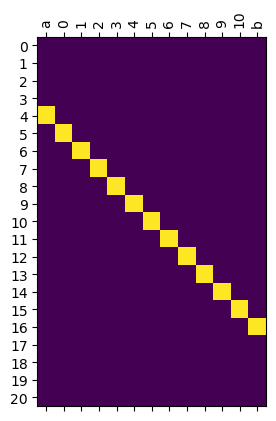

In [21]:
map, status = ilp_copy.solve_ilp(myAssgn)

map['phi_0_V'].draw()


In [12]:
ilp.solve_ilp(myAssgn)


({'phi_0_V': LabeledBlockMatrix(matrices={-4: LabeledMatrix(
  array=
  [], 
  rows=[0], 
  cols=[]), -3: LabeledMatrix(
  array=
  [], 
  rows=[1], 
  cols=[]), -2: LabeledMatrix(
  array=
  [], 
  rows=[2], 
  cols=[]), -1: LabeledMatrix(
  array=
  [], 
  rows=[3], 
  cols=[]), 0: LabeledMatrix(
  array=
  [[1.]], 
  rows=[4], 
  cols=['a']), 1: LabeledMatrix(
  array=
  [[1.]], 
  rows=[5], 
  cols=[0]), 2: LabeledMatrix(
  array=
  [[1.]], 
  rows=[6], 
  cols=[1]), 3: LabeledMatrix(
  array=
  [[1.]], 
  rows=[7], 
  cols=[2]), 4: LabeledMatrix(
  array=
  [[1.]], 
  rows=[8], 
  cols=[3]), 5: LabeledMatrix(
  array=
  [[1.]], 
  rows=[9], 
  cols=[4]), 6: LabeledMatrix(
  array=
  [[1.]], 
  rows=[10], 
  cols=[5]), 7: LabeledMatrix(
  array=
  [[1.]], 
  rows=[11], 
  cols=[6]), 8: LabeledMatrix(
  array=
  [[1.]], 
  rows=[12], 
  cols=[7]), 9: LabeledMatrix(
  array=
  [[1.]], 
  rows=[13], 
  cols=[8]), 10: LabeledMatrix(
  array=
  [[1.]], 
  rows=[14], 
  cols=[9]), 11: La